In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../Dataset/Mall_Customers.csv")

In [7]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

In [10]:
print(pca.explained_variance_ratio_)

[0.33690046 0.26230645]


So, the total variance captured is 0.33690046 + 0.26230645 = 0.5992(60%). 

Two principal components capture approximately 60% of the total information from the original dataset.

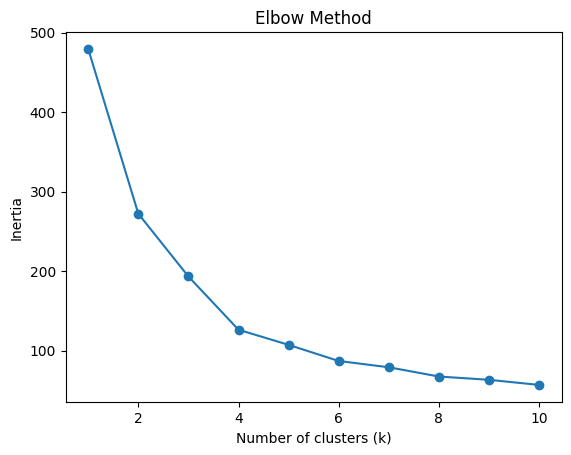

In [13]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()